<a href="https://colab.research.google.com/github/pavanichowdary19/MLOOPS/blob/main/MLops%20lab%203(employee).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132

In [2]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Employability_Dataset_1000 (1).csv to Employability_Dataset_1000 (1) (1).csv


In [4]:
df = pd.read_csv("Employability_Dataset_1000 (1).csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (1000, 21)


,Student_ID,Gender,Age,CGPA,SSC_Percentage,HSC_Percentage,Degree_Percentage,Python_Skill,Java_Skill,SQL_Skill,...,Communication,Problem_Solving,Aptitude_Score,Internship,Certifications,Projects,Hackathons,Resume_Score,Employability_Score,Industry_Ready
0,1001,Male,20,8.84,84.3,81.2,83.6,9,7,9,...,6,7,80,1,3,4,0,65,227.20,Yes
1,1002,Male,24,7.39,73.1,69.5,78.3,4,6,5,...,5,4,69,0,1,1,0,46,146.85,Yes
2,1003,Female,20,7.12,68.7,66.5,65.7,3,4,3,...,4,5,80,0,1,2,1,45,141.60,Yes
3,1004,Male,20,8.48,89.2,94.5,89.1,8,8,8,...,8,7,85,1,3,2,0,66,229.10,Yes
4,1005,Male,24,8.78,82.4,85.4,93.7,9,7,9,...,6,7,78,1,2,3,0,59,221.10,Yes


In [5]:
print("Columns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
df.info()

Columns:
['Student_ID', 'Gender', 'Age', 'CGPA', 'SSC_Percentage', 'HSC_Percentage', 'Degree_Percentage', 'Python_Skill', 'Java_Skill', 'SQL_Skill', 'DSA_Skill', 'Communication', 'Problem_Solving', 'Aptitude_Score', 'Internship', 'Certifications', 'Projects', 'Hackathons', 'Resume_Score', 'Employability_Score', 'Industry_Ready']

Data Types:
Student_ID               int64
Gender                  object
Age                      int64
CGPA                   float64
SSC_Percentage         float64
HSC_Percentage         float64
Degree_Percentage      float64
Python_Skill             int64
Java_Skill               int64
SQL_Skill                int64
DSA_Skill                int64
Communication            int64
Problem_Solving          int64
Aptitude_Score           int64
Internship               int64
Certifications           int64
Projects                 int64
Hackathons               int64
Resume_Score             int64
Employability_Score    float64
Industry_Ready          object
dtype

In [6]:
X = df.drop(
    columns=["Industry_Ready", "Student_ID"]
)

y = df["Industry_Ready"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.value_counts())

Features:
['Gender', 'Age', 'CGPA', 'SSC_Percentage', 'HSC_Percentage', 'Degree_Percentage', 'Python_Skill', 'Java_Skill', 'SQL_Skill', 'DSA_Skill', 'Communication', 'Problem_Solving', 'Aptitude_Score', 'Internship', 'Certifications', 'Projects', 'Hackathons', 'Resume_Score', 'Employability_Score']

Target:
Industry_Ready
Yes    711
No     289
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 19)
Testing Data: (200, 19)


In [8]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'CGPA', 'SSC_Percentage', 'HSC_Percentage', 'Degree_Percentage', 'Python_Skill', 'Java_Skill', 'SQL_Skill', 'DSA_Skill', 'Communication', 'Problem_Solving', 'Aptitude_Score', 'Internship', 'Certifications', 'Projects', 'Hackathons', 'Resume_Score', 'Employability_Score']

Categorical Features:
['Gender']


In [9]:
numerical_pipeline = Pipeline(
    steps=[
        ("missing_values", SimpleImputer(strategy="median")),
        ("scaling", StandardScaler())
    ]
)

In [10]:
categorical_pipeline = Pipeline(
    steps=[
        ("missing_values", SimpleImputer(strategy="most_frequent")),
        (
            "encoding",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [12]:
mlflow.set_experiment(
    "Employability Prediction"
)

print("Experiment created successfully.")

2026/08/24 06:25:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/24 06:25:09 INFO mlflow.store.db.utils: Updating database tables
2026/08/24 06:25:12 INFO mlflow.tracking.fluent: Experiment with name 'Employability Prediction' does not exist. Creating a new experiment.


Experiment created successfully.


In [14]:
with mlflow.start_run(
    run_name="Logistic Regression"
):

    model_pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            (
                "model",
                LogisticRegression(
                    C=1.0,
                    max_iter=1000
                )
            )
        ]
    )

    model_pipeline.fit(
        X_train,
        y_train
    )

    predictions = model_pipeline.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    mlflow.log_param(
        "model",
        "LogisticRegression"
    )

    mlflow.log_param(
        "C",
        1.0
    )

    mlflow.log_metric(
        "accuracy",
        accuracy
    )

    mlflow.sklearn.log_model(
        model_pipeline,
        name="model",
        skops_trusted_types=[
            "numpy.dtype",
            "sklearn.compose._column_transformer._RemainderColsList"
        ]
    )

    print(
        "Logistic Regression Accuracy:",
        accuracy
    )

Logistic Regression Accuracy: 0.97


In [16]:
with mlflow.start_run(
    run_name="Random Forest"
):

    model_pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=100,
                    max_depth=5,
                    random_state=42
                )
            )
        ]
    )

    model_pipeline.fit(
        X_train,
        y_train
    )

    predictions = model_pipeline.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    mlflow.log_param(
        "model",
        "RandomForest"
    )

    mlflow.log_param(
        "n_estimators",
        100
    )

    mlflow.log_param(
        "max_depth",
        5
    )

    mlflow.log_metric(
        "accuracy",
        accuracy
    )

    mlflow.sklearn.log_model(
        model_pipeline,
        name="model",
        skops_trusted_types=[
            "numpy.dtype",
            "sklearn.compose._column_transformer._RemainderColsList"
        ]
    )

    print(
        "Random Forest Accuracy:",
        accuracy
    )

Random Forest Accuracy: 1.0


In [17]:
models = {

    "LogisticRegression":
        LogisticRegression(
            C=1.0,
            max_iter=1000
        ),

    "DecisionTree":
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ),

    "RandomForest":
        RandomForestClassifier(
            n_estimators=100,
            max_depth=5,
            random_state=42
        )
}

In [19]:
for model_name, model in models.items():

    with mlflow.start_run(
        run_name=model_name
    ):

        pipeline = Pipeline(
            steps=[
                ("preprocessing", preprocessor),
                ("model", model)
            ]
        )

        pipeline.fit(
            X_train,
            y_train
        )

        predictions = pipeline.predict(
            X_test
        )

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        mlflow.log_param(
            "model",
            model_name
        )

        mlflow.log_params(
            model.get_params()
        )

        mlflow.log_metric(
            "accuracy",
            accuracy
        )

        mlflow.sklearn.log_model(
            pipeline,
            name="model",
            skops_trusted_types=[
                "numpy.dtype",
                "sklearn.compose._column_transformer._RemainderColsList"
            ]
        )

        print(
            model_name,
            "Accuracy:",
            round(accuracy, 4)
        )

LogisticRegression Accuracy: 0.97
DecisionTree Accuracy: 1.0
RandomForest Accuracy: 1.0


In [20]:
experiment = mlflow.get_experiment_by_name(
    "Employability Prediction"
)

runs = mlflow.search_runs(
    experiment_ids=[
        experiment.experiment_id
    ]
)

display(runs)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.accuracy,params.monotonic_cst,params.min_impurity_decrease,params.criterion,...,params.l1_ratio,params.penalty,params.fit_intercept,params.max_iter,params.tol,params.solver,tags.mlflow.source.name,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.source.type
0,0effdab5d7124638967c90b4ef529a3b,1,FINISHED,/content/mlruns/1/0effdab5d7124638967c90b4ef52...,2026-08-24 06:30:53.581000+00:00,2026-08-24 06:31:05.452000+00:00,1.00,None,0.0,gini,...,None,None,None,None,None,None,fileId=1OrZ8IoEcANxrsRA9FsX-g_gw9pMj1zww,root,RandomForest,NOTEBOOK
1,5d3a503b34d94c118ef060c3d749d07f,1,FINISHED,/content/mlruns/1/5d3a503b34d94c118ef060c3d749...,2026-08-24 06:30:42.754000+00:00,2026-08-24 06:30:53.562000+00:00,1.00,None,0.0,gini,...,None,None,None,None,None,None,fileId=1OrZ8IoEcANxrsRA9FsX-g_gw9pMj1zww,root,DecisionTree,NOTEBOOK
2,312a4f72764941ed9c6095df8d310df7,1,FINISHED,/content/mlruns/1/312a4f72764941ed9c6095df8d31...,2026-08-24 06:30:31.731000+00:00,2026-08-24 06:30:42.739000+00:00,0.97,None,None,None,...,None,l2,True,1000,0.0001,lbfgs,fileId=1OrZ8IoEcANxrsRA9FsX-g_gw9pMj1zww,root,LogisticRegression,NOTEBOOK
3,c91e3d4d15cf4ecc927256ceeb0457e9,1,FAILED,/content/mlruns/1/c91e3d4d15cf4ecc927256ceeb04...,2026-08-24 06:30:09.026000+00:00,2026-08-24 06:30:09.616000+00:00,0.97,None,None,None,...,None,l2,True,1000,0.0001,lbfgs,fileId=1OrZ8IoEcANxrsRA9FsX-g_gw9pMj1zww,root,LogisticRegression,NOTEBOOK
4,b26b8ba3e1824cb2ab70f982ee093d7b,1,FINISHED,/content/mlruns/1/b26b8ba3e1824cb2ab70f982ee09...,2026-08-24 06:27:39.774000+00:00,2026-08-24 06:27:51.584000+00:00,1.00,None,None,None,...,None,None,None,None,None,None,fileId=1OrZ8IoEcANxrsRA9FsX-g_gw9pMj1zww,root,Random Forest,NOTEBOOK
5,b38afb0e323d4b7296b4f07400ab758a,1,FAILED,/content/mlruns/1/b38afb0e323d4b7296b4f07400ab...,2026-08-24 06:26:52.849000+00:00,2026-08-24 06:26:53.751000+00:00,1.00,None,None,None,...,None,None,None,None,None,None,fileId=1OrZ8IoEcANxrsRA9FsX-g_gw9pMj1zww,root,Random Forest,NOTEBOOK
6,03d01d5eb8674c5bb3c7d6da53da13d8,1,FINISHED,/content/mlruns/1/03d01d5eb8674c5bb3c7d6da53da...,2026-08-24 06:26:18.892000+00:00,2026-08-24 06:26:33.399000+00:00,0.97,None,None,None,...,None,None,None,None,None,None,fileId=1OrZ8IoEcANxrsRA9FsX-g_gw9pMj1zww,root,Logistic Regression,NOTEBOOK
7,595115e7a85a48149daca6726ef1e7f5,1,FAILED,/content/mlruns/1/595115e7a85a48149daca6726ef1...,2026-08-24 06:25:21.633000+00:00,2026-08-24 06:25:44.162000+00:00,0.97,None,None,None,...,None,None,None,None,None,None,fileId=1OrZ8IoEcANxrsRA9FsX-g_gw9pMj1zww,root,Logistic Regression,NOTEBOOK


In [21]:
comparison = runs[
    [
        "tags.mlflow.runName",
        "params.model",
        "params.C",
        "params.max_depth",
        "params.n_estimators",
        "metrics.accuracy"
    ]
].copy()

comparison.columns = [
    "Run Name",
    "Model",
    "C",
    "Max Depth",
    "No. of Trees",
    "Accuracy"
]

comparison = comparison.dropna(
    subset=["Model", "Accuracy"]
)

comparison["Accuracy"] = (
    comparison["Accuracy"] * 100
).round(2)

comparison = comparison.sort_values(
    "Accuracy",
    ascending=False
)

display(comparison)

,Run Name,Model,C,Max Depth,No. of Trees,Accuracy
0,RandomForest,RandomForest,None,5,100,100.0
1,DecisionTree,DecisionTree,None,5,None,100.0
5,Random Forest,RandomForest,None,5,100,100.0
4,Random Forest,RandomForest,None,5,100,100.0
3,LogisticRegression,LogisticRegression,1.0,None,None,97.0
2,LogisticRegression,LogisticRegression,1.0,None,None,97.0
6,Logistic Regression,LogisticRegression,1.0,None,None,97.0
7,Logistic Regression,LogisticRegression,1.0,None,None,97.0


In [22]:
best_model = comparison.iloc[0]

print("BEST MODEL")
print("-------------------------")
print("Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"], "%")

BEST MODEL
-------------------------
Model: RandomForest
Accuracy: 100.0 %


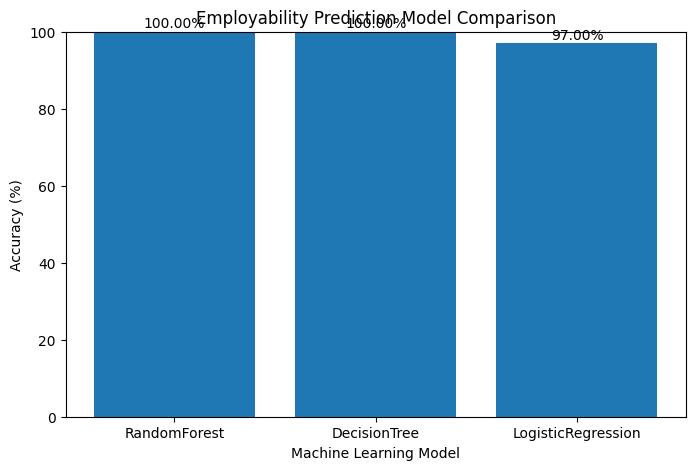

In [23]:
best_models = (
    comparison
    .drop_duplicates(subset=["Model"])
    .sort_values(
        "Accuracy",
        ascending=False
    )
)

plt.figure(figsize=(8, 5))

plt.bar(
    best_models["Model"],
    best_models["Accuracy"]
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.title(
    "Employability Prediction Model Comparison"
)

plt.ylim(0, 100)

for i, value in enumerate(
    best_models["Accuracy"]
):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

In [24]:
best_name = best_model["Model"]

best_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", models[best_name])
    ]
)

best_pipeline.fit(
    X_train,
    y_train
)

predictions = best_pipeline.predict(
    X_test
)

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

          No       1.00      1.00      1.00        58
         Yes       1.00      1.00      1.00       142

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [25]:
cm = confusion_matrix(
    y_test,
    predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 58   0]
 [  0 142]]


In [26]:
display(
    best_models[
        [
            "Model",
            "C",
            "Max Depth",
            "No. of Trees",
            "Accuracy"
        ]
    ]
    .style
    .format({
        "Accuracy": "{:.2f}%"
    })
    .highlight_max(
        subset=["Accuracy"],
        axis=0
    )
)

,Model,C,Max Depth,No. of Trees,Accuracy
0,RandomForest,None,5,100,100.00%
1,DecisionTree,None,5,None,100.00%
3,LogisticRegression,1.0,None,None,97.00%
